## MMTHE01 - Masters Thesis

### B. Thesis - Create a working model

1. Importing the final engineered dataset
2. Splitting the data into train and test data
3. Feature scaling
4. Model training

#### Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import time
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import LabelEncoder

In [2]:
### Import libraries to save models
import pickle
from tensorflow.keras.models import Model, load_model

In [3]:
# Check your current working directory
cwd = os.getcwd()

# Define your relative path
relative_path = r"Analysis"  # adjust this relative to cwd

# Build the full path
full_path = os.path.join(cwd, relative_path)

# Check if it exists before changing
if os.path.exists(full_path):
    os.chdir(full_path)
    print("Changed directory to:", full_path)
else:
    print("Folder does not exist:", full_path)

Changed directory to: C:\Users\eaber\Documents\Masters Thesis Final\Analysis


#### Importing the dataset

In [4]:
with open("saved_data/final_dataset.pkl","rb") as f:
    dataset = pickle.load(f)

In [5]:
dataset.head()

,acc_open_past_24mths,annual_inc,avg_cur_bal,bc_open_to_buy,bc_util,collections_12_mths_ex_med,delinq_2yrs,delinq_amnt,dti,earliest_cr_line_month_Apr,...,tot_hi_cred_lim,total_acc,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,total_rev_hi_lim,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,default_status
0,4.517166,33000.0,13533.888648,11418.697365,57.908076,0.000000,0.0,0.0,2.15,1.0,...,178248.102764,6.0,51080.557557,23226.657827,43762.092547,34606.178028,1.0,0.0,0.0,0
1,4.517166,12000.0,13533.888648,11418.697365,57.908076,0.018288,0.0,0.0,4.40,0.0,...,178248.102764,16.0,51080.557557,23226.657827,43762.092547,34606.178028,1.0,0.0,0.0,0
2,4.517166,59000.0,13533.888648,11418.697365,57.908076,0.000000,0.0,0.0,23.86,0.0,...,178248.102764,50.0,51080.557557,23226.657827,43762.092547,34606.178028,1.0,0.0,0.0,0
3,4.517166,98000.0,13533.888648,11418.697365,57.908076,0.000000,0.0,0.0,12.53,0.0,...,178248.102764,12.0,51080.557557,23226.657827,43762.092547,34606.178028,1.0,0.0,0.0,0
4,4.517166,7280.0,13533.888648,11418.697365,57.908076,0.018288,0.0,0.0,17.31,0.0,...,178248.102764,4.0,51080.557557,23226.657827,43762.092547,34606.178028,1.0,0.0,0.0,0


In [6]:
dataset.shape

(226067, 110)

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226067 entries, 0 to 226066
Columns: 110 entries, acc_open_past_24mths to default_status
dtypes: category(1), float64(104), int64(3), object(2)
memory usage: 188.2+ MB


### 5.1 Split the data into Train-Test

#### 5.1.1 Separate the features and the label

In [8]:
X = dataset.drop(columns=['default_status']).values
y = dataset['default_status'].values

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state = 1)

### 5.3 Feature Scaling

#### 5.3.1 Checking if the data has outliers

In [10]:
# Write a function to detect outliers using IQR method for each column
def detect_iqr_outliers(df):
    outlier_flags = pd.DataFrame(False, index=df.index, columns=df.columns)

    # Use the inter-quartile range to calculate outliers
    for col in df.select_dtypes(include=[int, float]).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Mark data points as false if not outliers and as true if outliers
        outlier_flags[col] = (df[col] < lower_bound) | (df[col] > upper_bound)

    return outlier_flags

In [11]:
# Call the function
outliers_df = detect_iqr_outliers(dataset)
outliers_df.head()

,acc_open_past_24mths,annual_inc,avg_cur_bal,bc_open_to_buy,bc_util,collections_12_mths_ex_med,delinq_2yrs,delinq_amnt,dti,earliest_cr_line_month_Apr,...,tot_hi_cred_lim,total_acc,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,total_rev_hi_lim,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,default_status
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
# For each column, count number of data points marked as false (not outliers) and as true (outliers)
outlier_count_df = outliers_df.apply(lambda col: col.value_counts()).T

In [13]:
# Extract results in to a CSV file
outlier_count_df.to_csv('outlier_count_df.csv')

#### 5.3.2 Feature Scaling

In [14]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

### 5.4 Baseline Model
* The logistic model is a weighted sum based model

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
# Build a LogisticRegression Base model
logR = LogisticRegression(random_state=1)

In [17]:
start_time = time.time()

In [18]:
# Train the LogisticRegression Base model
logR.fit(X_train_scaled, y_train)

LogisticRegression(random_state=1)

In [19]:
end_time = time.time()
training_time = end_time - start_time
print(f"LR Base Model Training Time: {training_time:.2f} seconds")

LR Base Model Training Time: 1.25 seconds


In [20]:
# Predict y given X_test_scaled
y_pred = logR.predict(X_test_scaled)
y_pred_proba = logR.predict_proba(X_test_scaled)

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:,1],pos_label=1)
auc_score = auc(fpr, tpr)
print("LR Base Model AUC (in %):", auc_score*100)

LR Base Model AUC (in %): 74.52225874113978


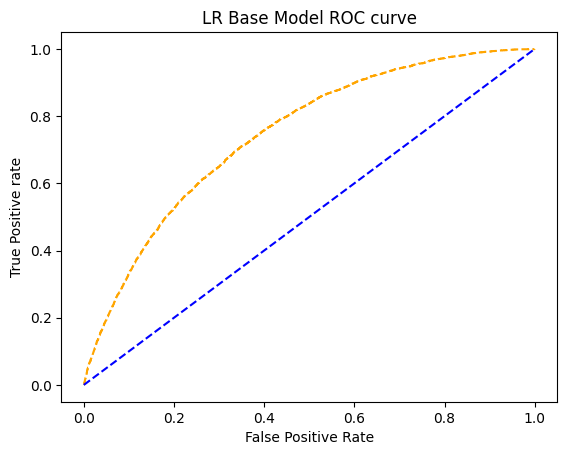

In [22]:
# ROC-AUC Curve
# plot roc curves
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, thresholds = roc_curve(y_test, random_probs, pos_label=1)
plt.plot(fpr, tpr, linestyle='--', color='orange')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
# title
plt.title('LR Base Model ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.savefig('LR Base Model ROC curve',dpi=300)
plt.show()

In [23]:
### Calculate recall_score of the baseline model to determine its sensitivity

sensitivity = recall_score(y_test, y_pred, pos_label=1)
print(f"LR Baseline Model Recall Score (Sensitivity): {sensitivity:.4f}")

LR Baseline Model Recall Score (Sensitivity): 0.0252


In [24]:
### Calculate precision_score of the baseline model

precision = precision_score(y_test, y_pred, pos_label=1)
print(f"LR Baseline Model Precision Score: {precision:.4f}")

LR Baseline Model Precision Score: 0.4037


In [25]:
f1 = f1_score(y_test, y_pred)
print(f"LR Baseline Model F1-score Score: {f1:.4f}")

LR Baseline Model F1-score Score: 0.0475


### 5.5 Supervised Learning Models

In [26]:
def find_best_threshold(y_true, y_pred_proba_or_score, thresholds=None):
    """
    Finds the best threshold for maximizing precision, recall, and F1-score.
    
    Parameters:
    - y_true: array-like of true labels (0/1)
    - y_pred_proba_or_score: predicted probabilities (or SVM decision scores)
    - thresholds: array-like of thresholds to evaluate (default: 0.0 to 1.0 step 0.01)
    
    Returns:
    - best_thresholds: dict with thresholds for max F1, recall, precision
    - metrics_at_best: dict with corresponding metrics at each best threshold
    """
    if thresholds is None:
        thresholds = np.arange(0.0, 1.01, 0.01)
    
    f1_scores = []
    recall_scores = []
    precision_scores = []
    
    for t in thresholds:
        y_pred = (y_pred_proba_or_score > t).astype(int)
        f1_scores.append(f1_score(y_true, y_pred, zero_division=0))

    best_threshold = thresholds[np.argmax(f1_scores)]
    
    return best_threshold

#### 5.5.1 Random Forest (RF)

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
# Build a Random Forest Model
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=1, class_weight='balanced')

In [29]:
start_time = time.time()

In [30]:
# Train the Random Forest Model
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=1)

In [31]:
end_time = time.time()
training_time = end_time - start_time
print(f"Random Forest Training Time: {training_time:.2f} seconds")

Random Forest Training Time: 106.59 seconds


In [32]:
# Predict y given X_test
y_pred_proba = rf.predict_proba(X_test)[:, 1]

In [33]:
## Determine optimal threshold for RF
chosen_threshold = find_best_threshold(y_test, y_pred_proba, thresholds=None)
chosen_threshold

0.55

In [34]:
y_pred = (y_pred_proba > chosen_threshold).astype(int)

In [35]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba,pos_label=1)
auc_score = auc(fpr, tpr)
print("Random Forest AUC (in %):", auc_score*100)

Random Forest AUC (in %): 76.27268448897739


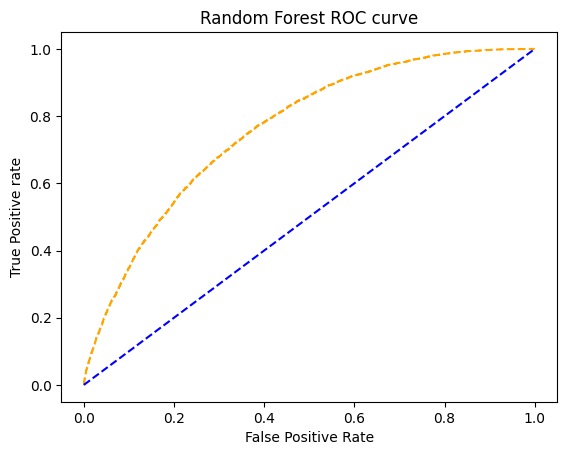

In [36]:
# ROC-AUC Curve
# plot roc curves
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, thresholds = roc_curve(y_test, random_probs, pos_label=1)
plt.plot(fpr, tpr, linestyle='--', color='orange')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
# title
plt.title('Random Forest ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.savefig('Random Forest ROC curve',dpi=300)
plt.show()

In [37]:
### Calculate recall_score of the Random Forest to determine its sensitivity

sensitivity = recall_score(y_test, y_pred, pos_label=1)
print(f"Random Forest Recall Score (Sensitivity): {sensitivity:.4f}")

Random Forest Recall Score (Sensitivity): 0.5764


In [38]:
### Calculate precision_score of the Random Forest

precision = precision_score(y_test, y_pred, pos_label=1)
print(f"Random Forest Precision Score: {precision:.4f}")

Random Forest Precision Score: 0.2558


In [39]:
# Save model
with open("saved_models/random_forest_model_original.pkl", "wb") as f:
    pickle.dump(rf, f)

#### 5.5.2 XGBoost

In [40]:
from xgboost import XGBClassifier

In [41]:
# Build an XGBoost Model
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=5,  # Adjust based on imbalance
    eval_metric='auc',
    random_state=1
)

In [42]:
start_time = time.time()

In [43]:
# Train the XGBoost model
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [44]:
end_time = time.time()
training_time = end_time - start_time
print(f"XGBoost Training Time: {training_time:.2f} seconds")

XGBoost Training Time: 8.90 seconds


In [45]:
# Predict y given X_test
y_pred_proba = xgb.predict_proba(X_test)[:, 1]

In [46]:
## Determine optimal threshold for XGB
chosen_threshold = find_best_threshold(y_test, y_pred_proba, thresholds=None)
chosen_threshold

0.55

In [47]:
y_pred = (y_pred_proba > chosen_threshold).astype(int)

In [48]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba,pos_label=1)
auc_score = auc(fpr, tpr)
print("XGBoost AUC (in %):", auc_score*100)

XGBoost AUC (in %): 77.41245049349284


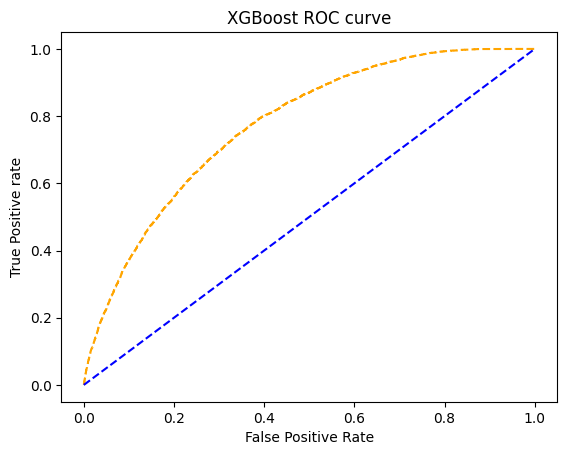

In [49]:
# ROC-AUC Curve
# plot roc curves
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, thresholds = roc_curve(y_test, random_probs, pos_label=1)
plt.plot(fpr, tpr, linestyle='--', color='orange')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
# title
plt.title('XGBoost ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.savefig('XGBoost ROC curve',dpi=300)
plt.show()

In [50]:
### Calculate recall_score of the XGBoost model to determine its sensitivity

sensitivity = recall_score(y_test, y_pred, pos_label=1)
print(f"XGBoost Recall Score (Sensitivity): {sensitivity:.4f}")

XGBoost Recall Score (Sensitivity): 0.4752


In [51]:
### Calculate precision_score of the XGBoost Model

precision = precision_score(y_test, y_pred, pos_label=1)
print(f"XGBoost Precision Score: {precision:.4f}")

XGBoost Precision Score: 0.2956


In [52]:
# Save model (JSON is preferred, supports portability)
xgb.save_model("saved_models/xgb_model_original.json")

#### 5.5.3 Artificial Neural Network (ANN)

In [53]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [54]:
# Compute class weights
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {i: class_weights[i] for i in range(len(classes))}

In [55]:
# Build Functional API ANN
inputs = Input(shape=(X_train_scaled.shape[1],), name='input_layer')
x = Dense(64, activation='relu', name='dense_1')(inputs)
x = Dropout(0.3, name='dropout_1')(x)
x = Dense(32, activation='relu', name='dense_2')(x)
x = Dropout(0.2, name='dropout_2')(x)
outputs = Dense(1, activation='sigmoid', name='output_layer')(x)

In [56]:
# Build an ANN model
model = Model(inputs=inputs, outputs=outputs, name='functional_ann')

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_AUC', patience=3, restore_best_weights=True, mode='max')

In [57]:
start_time = time.time()

In [58]:
# Train the ANN model with timing
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
566/566 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - AUC: 0.6462 - loss: 0.6649 - val_AUC: 0.7469 - val_loss: 0.5901
Epoch 2/50
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - AUC: 0.7367 - loss: 0.5995 - val_AUC: 0.7596 - val_loss: 0.5838
Epoch 3/50
566/566 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - AUC: 0.7504 - loss: 0.5831 - val_AUC: 0.7664 - val_loss: 0.5965
Epoch 4/50
566/566 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - AUC: 0.7593 - loss: 0.5767 - val_AUC: 0.7702 - val_loss: 0.5837
Epoch 5/50
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - AUC: 0.7644 - loss: 0.5733 - val_AUC: 0.7726 - val_loss: 0.5684
Epoch 6/50
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - AUC: 0.7661 - loss: 0.5731 - val_AUC: 0.7719 - val_loss: 0.5780
Epoch 7/50
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - AUC: 0.7691 - loss: 0.5661 - val_AUC: 0.7740 - val_loss: 0.5643
Epoch 8/50
566/566 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - AUC: 0.7750 - loss: 0.5609 - val_AUC: 0.7731 - val_loss: 0.5630
Epoch 9/50
566/566 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - A

In [59]:
end_time = time.time()
training_time = end_time - start_time
print(f"ANN Training Time: {training_time:.2f} seconds")

ANN Training Time: 46.50 seconds


In [60]:
# Predict y given X_test_scaled
y_pred_proba = model.predict(X_test_scaled)

1413/1413 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [61]:
## Determine optimal threshold for ANN
chosen_threshold = find_best_threshold(y_test, y_pred_proba, thresholds=None)
chosen_threshold

0.62

In [62]:
y_pred = (y_pred_proba > chosen_threshold).astype(int)

In [63]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba,pos_label=1)
auc_score = auc(fpr, tpr)
print("ANN AUC (in %):", auc_score*100)

ANN AUC (in %): 76.73192179773494


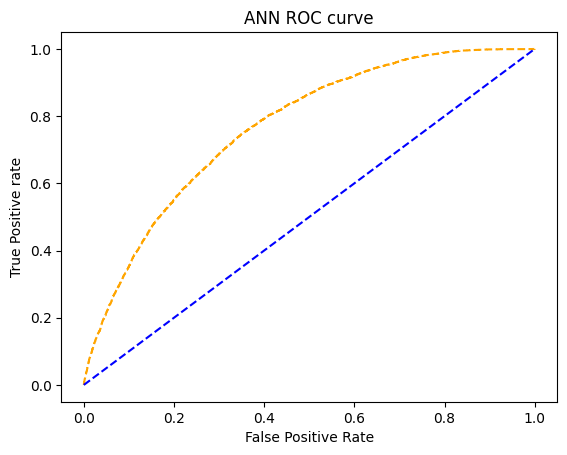

In [64]:
# ROC-AUC Curve
# plot roc curves
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, thresholds = roc_curve(y_test, random_probs, pos_label=1)
plt.plot(fpr, tpr, linestyle='--', color='orange')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
# title
plt.title('ANN ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.savefig('ANN ROC curve',dpi=300)
plt.show()

In [65]:
### Calculate recall_score of the ANN model to determine its sensitivity

sensitivity = recall_score(y_test, y_pred, pos_label=1)
print(f"ANN Recall Score (Sensitivity): {sensitivity:.4f}")

ANN Recall Score (Sensitivity): 0.4828


In [66]:
### Calculate precision_score of the ANN model

precision = precision_score(y_test, y_pred, pos_label=1)
print(f"ANN Precision Score {precision:.4f}")

ANN Precision Score 0.2868


In [67]:
# Save ANN
model.save("saved_models/ann_model_original.keras")

#### 5.5.4 Support Vector Machine (SVM) - Linear SVC

In [68]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

In [69]:
# Define pipeline with scaling + LinearSVC
pipeline = Pipeline([
    ('svc', LinearSVC(C=1.0, loss="squared_hinge", class_weight='balanced', max_iter=10000, random_state=1))
])

In [70]:
start_time = time.time()

In [71]:
# Fit the model
pipeline.fit(X_train_scaled, y_train)

Pipeline(steps=[('svc',
                 LinearSVC(class_weight='balanced', max_iter=10000,
                           random_state=1))])

In [72]:
end_time = time.time()
training_time = end_time - start_time
print(f"SVM Base Model Training Time: {training_time:.2f} seconds")

SVM Base Model Training Time: 12.28 seconds


In [73]:
# Predict y given X_test_scaled
y_pred_proba = pipeline.decision_function(X_test_scaled)

In [74]:
## Determine optimal threshold for SVM
chosen_threshold = find_best_threshold(y_test, y_pred_proba, thresholds=None)
chosen_threshold

0.19

In [75]:
y_pred = (y_pred_proba > chosen_threshold).astype(int)

In [76]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba,pos_label=1)
auc_score = auc(fpr, tpr)
print("SVM AUC (in %):", auc_score*100)

SVM AUC (in %): 74.60731177587265


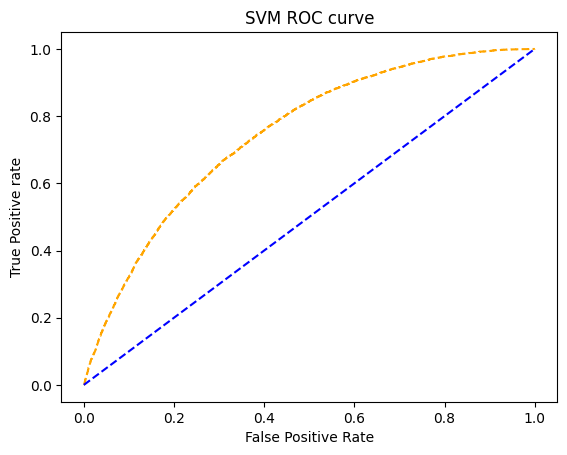

In [77]:
# ROC-AUC Curve
# plot roc curves
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, thresholds = roc_curve(y_test, random_probs, pos_label=1)
plt.plot(fpr, tpr, linestyle='--', color='orange')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
# title
plt.title('SVM ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.savefig('SVM ROC curve',dpi=300)
plt.show()

In [78]:
### Calculate recall_score of the SVM model to determine its sensitivity

sensitivity = recall_score(y_test, y_pred, pos_label=1)
print(f"SVM Recall Score (Sensitivity): {sensitivity:.4f}")

SVM Recall Score (Sensitivity): 0.4897


In [79]:
### Calculate precision_score of the SVM model

precision = precision_score(y_test, y_pred, pos_label=1)
print(f"SVM Precision Score {precision:.4f}")

SVM Precision Score 0.2639


In [80]:
# Save model
with open("saved_models/svm_pipeline_original.pkl", "wb") as f:
    pickle.dump(pipeline, f)

#### 5.5.6 Gradient Boosting Machine (GBM)

In [81]:
from sklearn.ensemble import GradientBoostingClassifier

In [82]:
# Define GBM model
gbm = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    random_state=1
)

In [83]:
start_time = time.time()

In [84]:
gbm.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=5, random_state=1, subsample=0.8)

In [85]:
end_time = time.time()
training_time = end_time - start_time
print(f"GBM Training Time: {training_time:.2f} seconds")

GBM Training Time: 705.74 seconds


In [86]:
# Predict y given X_test
y_pred_proba = gbm.predict_proba(X_test)[:,1]

In [87]:
## Determine optimal threshold for GBM
chosen_threshold = find_best_threshold(y_test, y_pred_proba, thresholds=None)
chosen_threshold

0.17

In [88]:
y_pred = (y_pred_proba > chosen_threshold).astype(int)

In [89]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba,pos_label=1)
auc_score = auc(fpr, tpr)
print("GBM AUC (in %):", auc_score*100)

GBM AUC (in %): 77.43987536374225


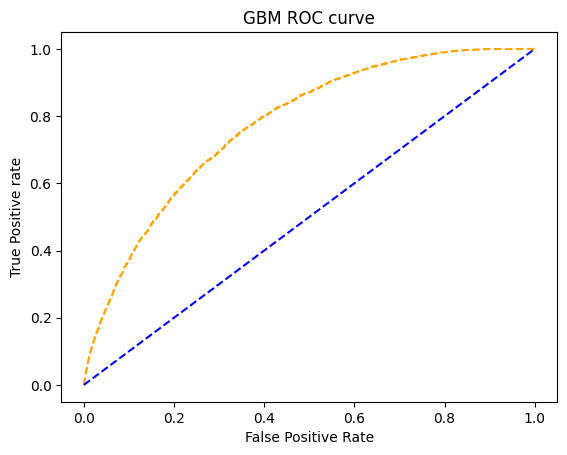

In [90]:
# ROC-AUC Curve
# plot roc curves
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, thresholds = roc_curve(y_test, random_probs, pos_label=1)
plt.plot(fpr, tpr, linestyle='--', color='orange')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
# title
plt.title('GBM ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.savefig('GBM ROC curve',dpi=300)
plt.show()

In [91]:
### Calculate recall_score of the baseline model to determine its sensitivity

sensitivity = recall_score(y_test, y_pred, pos_label=1)
print(f"GBM Recall Score (Sensitivity): {sensitivity:.4f}")

GBM Recall Score (Sensitivity): 0.5699


In [92]:
### Calculate precision_score of the SVM model

precision = precision_score(y_test, y_pred, pos_label=1)
print(f"GBM Precision Score {precision:.4f}")

GBM Precision Score 0.2694


In [93]:
# Save model
with open("saved_models/gbm_model_original.pkl", "wb") as f:
    pickle.dump(gbm, f)